# Image and Video Processing Lab 7

### Import Libraries

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import convolve2d

### Helper Functions

In [27]:
def show(title, img):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

def normalize(img):
    return (img - np.min(img)) / (np.max(img) - np.min(img))

def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return 100
    return 10 * np.log10(1.0 / mse)

### Load Image

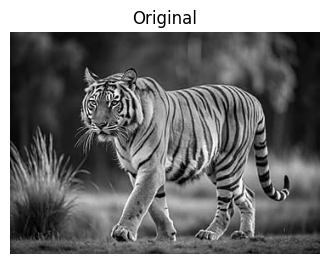

In [28]:
img = cv2.imread('tiger.jpg', cv2.IMREAD_GRAYSCALE)

img = np.float32(img) / 255.0

plt.figure(figsize=(4,4))
show("Original", img)

### Experiment 1: Wavelet Denoising

In [29]:
noise = np.random.normal(0, 0.1, img.shape)
noisy = img + noise
noisy = np.clip(noisy, 0, 1)

#### Wavelet Tranform + Thresholding

In [30]:
coeffs = pywt.wavedec2(noisy, 'haar', level=2)

# Apply threshold
threshold = 0.1
coeffs_thresh = []

for c in coeffs:
    if isinstance(c, tuple):
        coeffs_thresh.append(tuple(pywt.threshold(subband, threshold, mode='soft') for subband in c))
    else:
        coeffs_thresh.append(c)

denoised = pywt.waverec2(coeffs_thresh, 'haar')
denoised = np.clip(denoised, 0, 1)

PSNR (Noisy): 20.325223372811024
PSNR (Denoised): 24.077947948846166


<Figure size 1000x400 with 0 Axes>

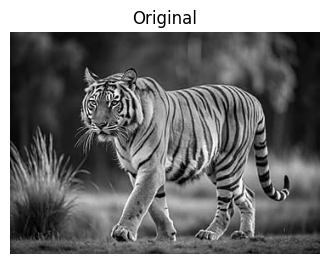

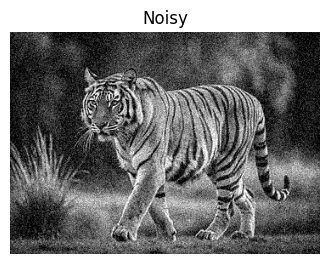

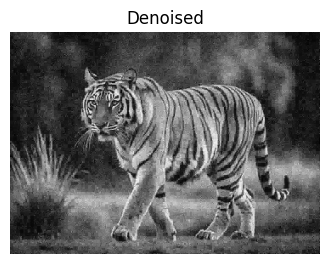

In [38]:
plt.figure(figsize=(10,4))

plt.figure(figsize=(4,4))
show("Original", img)

plt.figure(figsize=(4,4))
show("Noisy", noisy)

plt.figure(figsize=(4,4))
show("Denoised", denoised)

denoised = pywt.waverec2(coeffs_thresh, 'haar')
denoised = np.clip(denoised, 0, 1)

# FIX: match shape
denoised = denoised[:img.shape[0], :img.shape[1]]

print("PSNR (Noisy):", psnr(img, noisy))
print("PSNR (Denoised):", psnr(img, denoised))

### Experiment 2: Wavelet Compression

In [32]:
coeffs = pywt.wavedec2(img, 'haar', level=2)

threshold = 0.05
coeffs_comp = []

for c in coeffs:
    if isinstance(c, tuple):
        coeffs_comp.append(tuple(pywt.threshold(subband, threshold, mode='hard') for subband in c))
    else:
        coeffs_comp.append(c)

compressed = pywt.waverec2(coeffs_comp, 'haar')
compressed = np.clip(compressed, 0, 1)

<Figure size 1000x400 with 0 Axes>

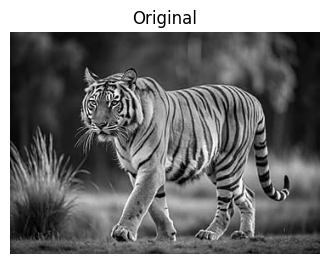

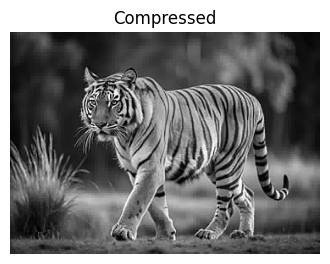

PSNR (Compressed): 36.64553


In [33]:
plt.figure(figsize=(10,4))

plt.figure(figsize=(4,4))
show("Original", img)
plt.show()

plt.figure(figsize=(4,4))
show("Compressed", compressed)
plt.show()

compressed = pywt.waverec2(coeffs_comp, 'haar')
compressed = np.clip(compressed, 0, 1)

# FIX
compressed = compressed[:img.shape[0], :img.shape[1]]

print("PSNR (Compressed):", psnr(img, compressed))

### Experiment 3: Image Deblurring

#### Create Blur

In [34]:
kernel = np.ones((5,5)) / 25
blurred = convolve2d(img, kernel, mode='same', boundary='wrap')

#### Inverse Filter (Frequency Domain)

In [35]:
H = np.fft.fft2(kernel, s=img.shape)
G = np.fft.fft2(blurred)

# Avoid division by zero
epsilon = 1e-3
F_hat = G / (H + epsilon)

inverse_img = np.abs(np.fft.ifft2(F_hat))

#### Wiener Filter

In [36]:
K = 0.01  # noise-to-signal ratio

H_conj = np.conj(H)
wiener = (H_conj / (np.abs(H)**2 + K)) * G

wiener_img = np.abs(np.fft.ifft2(wiener))

#### Display

<Figure size 1200x400 with 0 Axes>

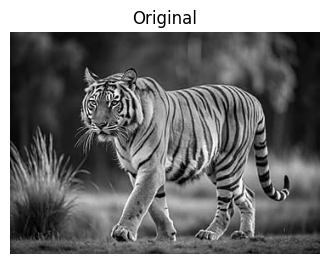

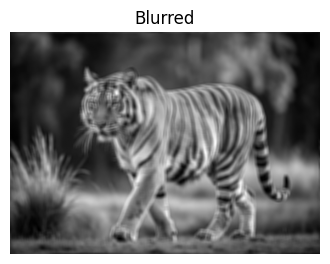

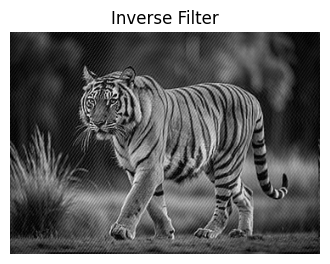

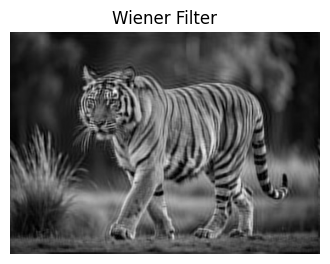

PSNR Inverse: 15.25317874590198
PSNR Wiener: 16.53749095389904


In [37]:
plt.figure(figsize=(12,4))

plt.figure(figsize=(4,4))
show("Original", img)
plt.show()

plt.figure(figsize=(4,4))
show("Blurred", blurred)
plt.show()

plt.figure(figsize=(4,4))
show("Inverse Filter", normalize(inverse_img))
plt.show()

plt.figure(figsize=(4,4))
show("Wiener Filter", normalize(wiener_img))
plt.show()

print("PSNR Inverse:", psnr(img, inverse_img))
print("PSNR Wiener:", psnr(img, wiener_img))

- Wavelet denoising effectively removes noise while preserving structure.
- Compression via wavelets retains important features with fewer coefficients.
- Inverse filtering is sensitive to noise, while Wiener filtering provides more stable restoration.